#Ensemble Techniques

Techniques to use more than one model together instead of one model to increase the performance & the Accuracy

1. reduce the error
2. reduce overfitting
3. increase accuracy
4. increase performance (better predictions)

#Ensemble Techniques
1. Bagging
2. boosting

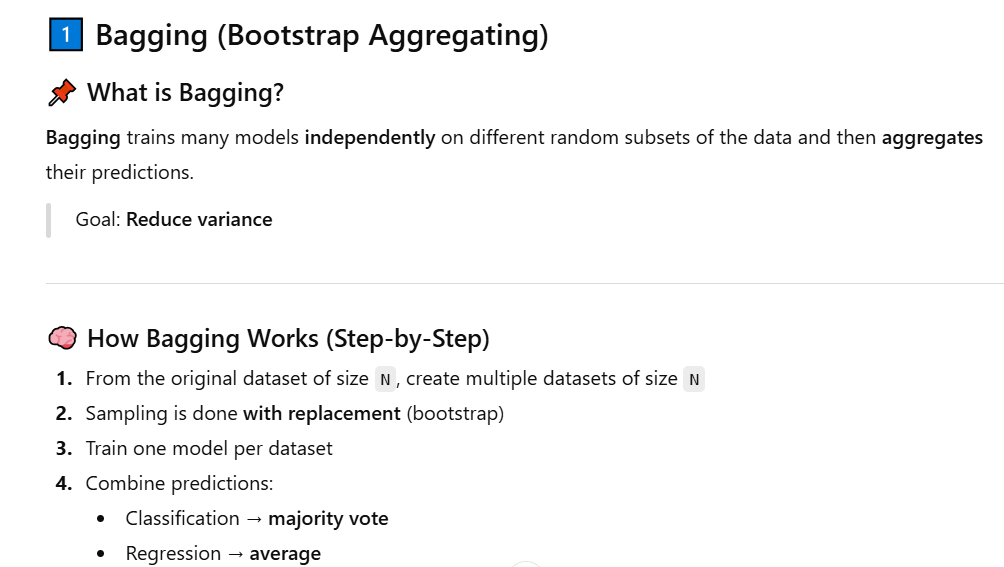

# very Important
Training in bagging : parallel

In [ ]:
from sklearn.ensemble import BaggingClassifier # New
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load dataset
df=pd.read_csv("/content/breast_cancer.csv")

#split x,y
x=df.drop("target",axis=1)
y=df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# Base model
base_tree = DecisionTreeClassifier(random_state=42)

# Bagging Classifier
bagging_clf = BaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    random_state=42,
    n_jobs=-1 #   CPU Cores
)

# Train
bagging_clf.fit(X_train, y_train)

# Predict
y_pred = bagging_clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.958041958041958


#Boosting

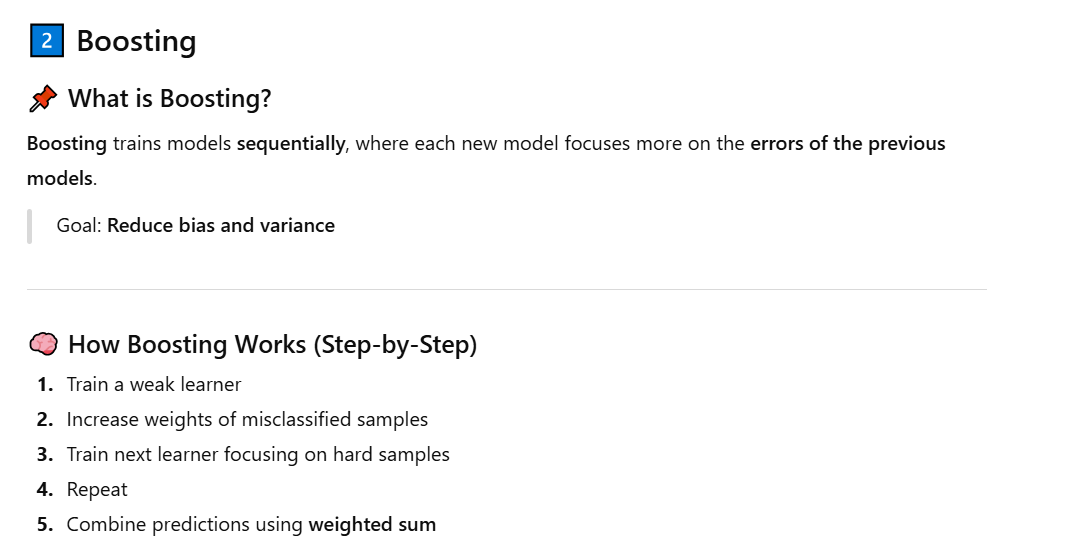

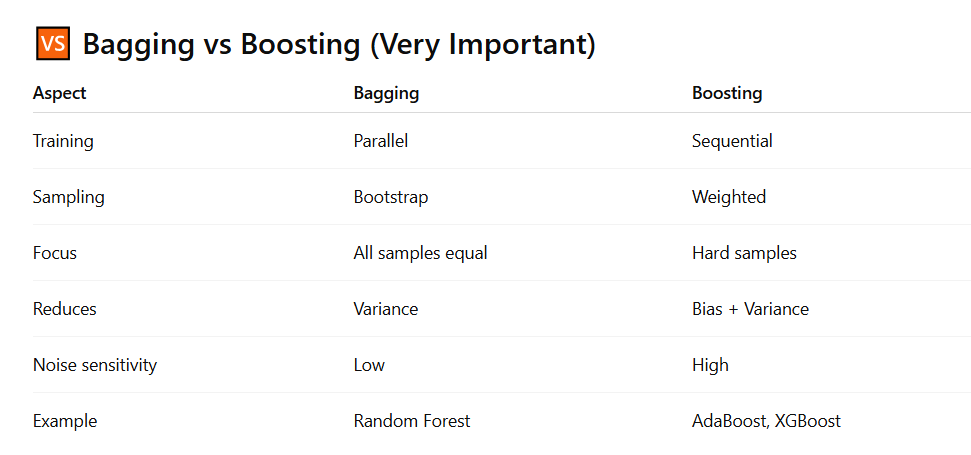

In [ ]:
# 1️⃣ Imports

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier # new
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


import pandas as pd

# Load dataset
df=pd.read_csv("/content/breast_cancer.csv")

#split x,y
x=df.drop("target",axis=1)
y=df['target']


# 2️⃣ Load dataset
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# 3️⃣ Base model for boosting (weak learner)
base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # weak learner

# 4️⃣ Create AdaBoost Classifier
boost_clf = AdaBoostClassifier(
    estimator=base_tree,   # weak learner
    n_estimators=50,       # number of boosting rounds
    learning_rate=0.4,
    random_state=42
)

# 5️⃣ Train model
boost_clf.fit(X_train, y_train)

# 6️⃣ Predict
y_pred = boost_clf.predict(X_test)

# 7️⃣ Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.972027972027972


#What about build custom bagging ?

In [ ]:
# 1️⃣ Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample # new
from scipy.stats import mode # new
import numpy as np
import pandas as pd


# Load dataset
df=pd.read_csv("/content/breast_cancer.csv")

#split x,y
x=df.drop("target",axis=1)
y=df['target']


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# Define  models
estimators = [
    ("DecisionTree", DecisionTreeClassifier(max_depth=4, random_state=42)),
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5))
]

# Train each model on a bootstrap sample
for name, model in estimators:
    X_sample, y_sample = resample(X_train, y_train, n_samples=len(X_train), random_state=42)
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Aggregate predictions (majority voting)
all_predictions = []

for _, model in estimators:
    preds = model.predict(X_test)
    all_predictions.append(preds)

all_predictions = np.array(all_predictions)

y_pred_ensemble, _ = mode(all_predictions, axis=0)

print("\nBagging Ensemble Accuracy:", accuracy_score(y_test, y_pred_ensemble))

DecisionTree Accuracy: 0.9231
LogisticRegression Accuracy: 0.9580
KNN Accuracy: 0.9371

Heterogeneous Bagging Ensemble Accuracy: 0.972027972027972


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
all_predictions

array([[1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1],
       [1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 0, 1, 1, 0, 0,

In [ ]:
y_pred_ensemble

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1])

In [ ]:
from scipy.stats import mode
import numpy as np

data = np.array([
    [1, 0, 1],
    [1, 1, 1],
    [0, 1, 1]
])

result = mode(data, axis=0)

print(result)

ModeResult(mode=array([1, 1, 1]), count=array([2, 2, 3]))


#ٌRegression

In [2]:
#Imports

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.utils import resample
import numpy as np
import pandas as pd


# Load dataset
df=pd.read_excel("/content/my_data_3.xlsx")

#split x,y
x=df.drop("Price",axis=1)
y=df['Price']


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

# Define regressors
estimators = [
    ("DecisionTree", DecisionTreeRegressor(max_depth=8, random_state=42)),
    ("LinearRegression", LinearRegression()),
    ("KNN", KNeighborsRegressor(n_neighbors=5))
]

# Train each regressor on a bootstrap sample
for name, model in estimators:
    X_sample, y_sample = resample(X_train, y_train, n_samples=len(X_train), random_state=42)
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_test)
    print(f"{name} MSE: {mean_squared_error(y_test, y_pred):.4f}, R2: {r2_score(y_test, y_pred):.4f}")

# Aggregate predictions (average for regression)
all_predictions = []

for _, model in estimators:
    preds = model.predict(X_test)
    all_predictions.append(preds)

all_predictions = np.array(all_predictions)

y_pred_ensemble = np.mean(all_predictions, axis=0)

print("\n Bagging Ensemble MSE:", mean_squared_error(y_test, y_pred_ensemble))
print(" Bagging Ensemble R2:", r2_score(y_test, y_pred_ensemble))


DecisionTree MSE: 0.0000, R2: 1.0000
LinearRegression MSE: 0.0000, R2: 1.0000
KNN MSE: 1.0858, R2: 0.1795

 Bagging Ensemble MSE: 0.12067070328335866
 Bagging Ensemble R2: 0.9088051298305944
